In [16]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict, Annotated
from dotenv import load_dotenv
import os
from pydantic import BaseModel, Field
import operator

In [17]:
load_dotenv(override=True)

True

In [18]:
# Initialize Gemini Model
api_key = os.getenv('GEMINI_API_KEY') or os.getenv('GOOGLE_API_KEY')
model = ChatGoogleGenerativeAI(
    model='gemini-3.6-flash',
    google_api_key=api_key
)

In [19]:
class EvaluationSchema(BaseModel):
    feedback: str = Field(description='detailed feedback for the essay')
    score: float = Field(description='score out of 10', ge=0, le=10)

In [20]:
structured_model = model.with_structured_output(EvaluationSchema)

In [21]:
essay = """
Essay on India

India is one of the oldest and most fascinating civilizations in the world. It is a country known for its rich history, diverse culture, beautiful landscapes, and rapid modern development. Located in South Asia, India is the seventh-largest country by area and the most populous democracy in the world. It is often described as a land of “Unity in Diversity” because people of different languages, religions, traditions, and lifestyles live together in harmony.

Historical Importance

India has a glorious past that dates back thousands of years. Ancient civilizations such as the Indus Valley Civilization flourished on this land. Over time, great empires like the Maurya, Gupta, Mughal, and many regional kingdoms contributed to India’s cultural and architectural heritage. The country was under British rule for many years, but after a long struggle led by leaders such as Mahatma Gandhi, Jawaharlal Nehru, and Sardar Vallabhbhai Patel, India gained independence on 15 August 1947.

Cultural Diversity

One of the greatest strengths of India is its cultural diversity. The country is home to many religions, including Hinduism, Islam, Christianity, Sikhism, Buddhism, and Jainism. Each religion has its own customs and festivals, which are celebrated with great enthusiasm. Festivals such as Diwali, Holi, Eid, Christmas, Durga Puja, and Onam reflect the vibrant spirit of the nation.

India also has a remarkable linguistic heritage. The Constitution recognizes 22 official languages, while hundreds of other languages and dialects are spoken across the country. Despite these differences, Indians share a strong sense of national identity.

Natural Beauty

India is blessed with diverse geographical features. In the north stand the majestic Himalayas, while the west has the vast Thar Desert. The south is surrounded by the Arabian Sea, the Indian Ocean, and the Bay of Bengal, giving India a long and beautiful coastline. Dense forests, fertile plains, waterfalls, backwaters, and wildlife sanctuaries add to the country’s natural charm.

Indian Cuisine

Indian food is famous throughout the world for its variety and flavors. Different regions have their own specialties. North India is known for dishes like biryani, naan, and paneer, while South India is famous for dosa, idli, and sambar. Street foods such as pani puri, vada pav, and chaat are loved by millions.

Modern India

Today, India is making rapid progress in science, technology, education, and industry. Cities such as Bengaluru, Hyderabad, and Pune have become important centers of information technology. India has also achieved significant success in space research through organizations like ISRO, which has launched missions to the Moon and Mars.

However, India still faces challenges such as poverty, unemployment, pollution, and inequality. The government and citizens are continuously working toward building a cleaner, healthier, and more prosperous nation.

Conclusion

India is a unique country where ancient traditions coexist with modern advancements. Its history, culture, spirituality, and diversity make it truly special. Every region of India has its own beauty and contribution to the nation. As citizens, we should respect our diversity, protect our environment, and work together for the progress of our country. India is not only a land of great heritage but also a nation with immense potential and a bright future.

Jai Hind! 🇮🇳
"""

In [22]:
essay2 = """
India is a very good country and it have many peoples. The peoples are living in different states and speaking many languages. India are famous for culture and festival.

India got freedom in 1947 and many leader fighted for independence. Mahatma Gandhi was one of the famous leader. New Delhi are the capital of India.

There is many beautiful place in India. Himalaya is very big mountain and Ganga is a holy river. Tourist comes from many country for seeing India.

Indian foods is very tasty. I likes dosa, samosa and biryani. Different state have different food and dress.

India is also developing in science and technology. ISRO sended many rocket to space and it make India proud.

But India also have many problem like pollution, traffic and poverty. Government are trying to solving these problems.

I love India because it is my country. We should respect our national flag and help to making India better in future.

Jai Hind. 🇮🇳
"""

In [23]:
class UPSCState(TypedDict):
    essay: str
    language_feedback: str
    analysis_feedback: str
    clarity_feedback: str
    overall_feedabck: str
    individual_scores: Annotated[list[int], operator.add]
    avg_score: float

In [24]:
def evaluate_language(state: UPSCState):
    prompt = f'Evaluete the language quality of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response = structured_model.invoke(prompt)
    return { 'language_feedback': response.feedback, 'individual_scores': [response.score] }

In [25]:
def evaluate_analysis(state: UPSCState):
    prompt = f'Evaluete the depth of analysis of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response = structured_model.invoke(prompt)
    return { 'clarity_feedback': response.feedback, 'individual_scores': [response.score] }

In [26]:
def evaluate_thought(state: UPSCState):
    prompt = f'Evaluete the clarity of thought of the following essay and provide a feedback and assign a score out of 10 \n {essay}'
    response = structured_model.invoke(prompt)
    return { 'analysis_feedback': response.feedback, 'individual_scores': [response.score] }

In [27]:
def final_evaluation(state: UPSCState):
    prompt = f'Based on the following feedbacks create a summarized feedback \n language feedback {state["language_feedback"]} \n depth of analysis feedback - {state["analysis_feedback"]} \n clarity of through feedback - {state["clarity_feedback"]}'
    overall_feedback = model.invoke(prompt).content
    avg_score = sum(state['individual_scores'])/len(state['individual_scores'])
    return { 'overall_feedabck': overall_feedback, 'avg_score': avg_score }

In [28]:
graph = StateGraph(UPSCState)

graph.add_node('evaluate_language', evaluate_language)
graph.add_node('evaluate_analysis', evaluate_analysis)
graph.add_node('evaluate_thought', evaluate_thought)
graph.add_node('final_evaluation', final_evaluation)


graph.add_edge(START, 'evaluate_language')
graph.add_edge(START, 'evaluate_analysis')
graph.add_edge(START, 'evaluate_thought')
graph.add_edge('evaluate_language', 'final_evaluation')
graph.add_edge('evaluate_analysis', 'final_evaluation')
graph.add_edge('evaluate_thought', 'final_evaluation')


workflow = graph.compile()

In [29]:
intial_state = {
    'essay': essay2
}

workflow.invoke(intial_state)

{'essay': '\nIndia is a very good country and it have many peoples. The peoples are living in different states and speaking many languages. India are famous for culture and festival.\n\nIndia got freedom in 1947 and many leader fighted for independence. Mahatma Gandhi was one of the famous leader. New Delhi are the capital of India.\n\nThere is many beautiful place in India. Himalaya is very big mountain and Ganga is a holy river. Tourist comes from many country for seeing India.\n\nIndian foods is very tasty. I likes dosa, samosa and biryani. Different state have different food and dress.\n\nIndia is also developing in science and technology. ISRO sended many rocket to space and it make India proud.\n\nBut India also have many problem like pollution, traffic and poverty. Government are trying to solving these problems.\n\nI love India because it is my country. We should respect our national flag and help to making India better in future.\n\nJai Hind. 🇮🇳\n',
 'language_feedback': 'The 

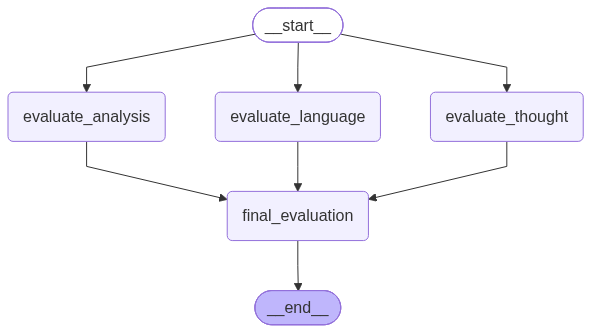

In [30]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())